## Data Preparation and Pysster Motif Prediction Pipeline


In [1]:
import pandas as pd
import numpy as np
import subprocess, os, re
from collections import defaultdict
from pyCRAC.Parsers import GTF2

In [12]:
#helpers: 
#get gene name
def get_gene_names(row):
    attr = row["attributes"]
    names_end = int(re.search(r"\"(?=[^\"]*$)", attr).start())
    names_start = int(re.search(r"gene_name", attr).end() + 2)
    names = attr[names_start:names_end].split(",")
    return names
#get gene id
def get_gene_ids(row):
    attr = row["attributes"]
    ids_start = int(re.search(r"\"", attr).start() +1)
    ids_end = int(re.search(r"\";", attr).start())
    ids = attr[ids_start:ids_end].split(",")
    return ids

def get_gene_list(df):
    gene_set = set()
    for i, row in df.iterrows():
        gene_set.update(get_gene_names(row))
    gene_set.discard("no_matches")
    gene_list = list(gene_set)
    return gene_list

def add_header(df):
    # chromosome	feature	source	start	end	peak_height	strand	FDR	attributes
    header = ["chromosome", "feature", "source", "start", "end", "peak_height", "strand", "FDR", "attributes"]
    df.columns = header  
    return df
#writing to gtf
#gtf: 1 based, inclusive
def write_to_gtf(df, out_file):
    df_out = df.copy()
    df_out["start"] = df_out["start"].astype(int) + 1
    df_out["end"] = df_out["end"].astype(int) +1
    df_out.to_csv(out_file, sep="\t", index=False, header=False, quoting=3)

def read_gtf(in_file):
    #header: chromosome	feature	source	start	end	peak_height	strand	FDR	attributes
    df = pd.read_csv(in_file, sep="\t", comment="#", header=None)
    add_header(df)
    df["start"] = df["start"].astype(int) - 1 #convert to python indices
    df["end"] = df["end"].astype(int) - 1
    return df

#parse gtf annotation
def gtf_parse(gtf_annot):
    gtf = GTF2.Parse_GTF()
    gtf.read_GTF(gtf_annot)
    return gtf

In [ ]:
#input files
gtf_annot = "/home/s2850039/clip-gnn-pipeline-main/data/Ssd1_CRAC_training_data/Saccharomyces_cerevisiae.EF4.74_SGDv64_CUTandSUT_withUTRs_noEstimates_antisense_intergenic_4xlncRNAs_final.pyCheckGTFfile.output.quotefix.gtf"
genome_file = "/home/s2850039/clip-gnn-pipeline-main/data/Ssd1_CRAC_training_data/Saccharomyces_cerevisiae.EF4.74.dna.toplevel.shortChrNames.fa"
chr_len = "/home/s2850039/clip-gnn-pipeline-main/data/Ssd1_CRAC_training_data/Saccharomyces_cerevisiae.EF4.74.dna.toplevel.shortChrNames.lengths"
length = str(100)
sig = 0.05
protein="Ssd1"

#parse gtf annot
gtf = gtf_parse(gtf_annot)


In [14]:

interval_file = "/home/s2850039/clip-gnn-pipeline-main/data/Ssd1_CRAC_training_data/Ssd1_merged_peaks.gtf"
name=interval_file[re.search(r"\/",interval_file).end():re.search(r"\.gtf",interval_file).start()]
#ouputs
output_folder = f"outputs_{protein}_{length}nt"
if not os.path.isdir(output_folder):
    os.makedirs(output_folder)
norm_interval_file = f"{output_folder}/{protein}peaks_norm{length}.gtf"

**normalize interval lengths**

In [15]:
#normalize intervals
subprocess.call(["pyNormalizeIntervalLengths.py", "-f", interval_file, "--fixed", length, "-o", norm_interval_file, "-c", chr_len])

0

## Data Preparation

In [16]:
#load gtf
df_intervals_all = read_gtf(norm_interval_file)
df_intervals = df_intervals_all[df_intervals_all["FDR"] <0.05]
df_intervals

,chromosome,feature,source,start,end,peak_height,strand,FDR,attributes
0,chrV,cluster,interval,227,327,5.0,-,0.0,"gene_id ""YEL077C""; gene_name ""YEL077C"";"
1,chrV,cluster,interval,319,419,11.0,-,0.0,"gene_id ""YEL077C""; gene_name ""YEL077C"";"
2,chrXIV,cluster,interval,328,428,5.0,-,0.0,"gene_id ""YNL339C""; gene_name ""YRF1-6"";"
3,chrX,cluster,interval,435,535,5.0,-,0.0,"gene_id ""YJL225C""; gene_name ""YJL225C"";"
4,chrIX,cluster,interval,452,552,7.0,-,0.0,"gene_id ""YIL177C""; gene_name ""YIL177C"";"
...,...,...,...,...,...,...,...,...,...
25989,chrIV,cluster,interval,1520661,1520761,12.0,-,0.0,"gene_id ""YDR541C""; gene_name ""YDR541C"";"
25990,chrIV,cluster,interval,1520664,1520764,22.0,-,0.0,"gene_id ""YDR541C""; gene_name ""YDR541C"";"
25991,chrIV,cluster,interval,1520666,1520766,6.0,-,0.0,"gene_id ""YDR541C""; gene_name ""YDR541C"";"
25992,chrIV,cluster,interval,1520773,1520873,11.0,-,0.0,"gene_id ""YDR541C""; gene_name ""YDR541C"";"


**Interval overlap detection**

In [17]:
#find overlaps + group intervals
def find_overlaps(df):
    grouped_dfs = []
    for (chromosome, strand), subdf in df.groupby(["chromosome", "strand"]):
        group_ids = []
        current_group = 0
        current_group_end = None
        subdf = subdf.sort_values("start").copy()
        for i, row in subdf.iterrows():
            start = int(row["start"])
            end = int(row["end"])
            if not current_group_end or start >= current_group_end:
                current_group+=1
            current_group_end = end
            group_ids.append(current_group)
        subdf["overlap_sub_group"] = group_ids
        subdf["overlap_group"] = str(chromosome) + "_" + str(strand) + "_" + subdf["overlap_sub_group"].astype(str)
        grouped_dfs.append(subdf)

    df = pd.concat(grouped_dfs)
    #identify overlap groups
    counts = df["overlap_group"].value_counts()
    df["has_overlap"] = df["overlap_group"].map(counts) > 1

    groups = df[df["has_overlap"]==True]
    return groups

groups = find_overlaps(df_intervals)
groups.to_csv(f"{output_folder}/{protein}peaks_norm{length}_groups.tsv", sep="\t", index=False)

#overlap group counts
group_counts = groups["overlap_group"].value_counts().reset_index()
group_counts = pd.DataFrame(group_counts)
group_counts.columns = ["Group", "num_intervals"]
group_counts.to_csv(f"{output_folder}/{protein}peaks_norm{length}_overlap_group_counts.tsv", sep="\t", index=False)


**Interval overlap exclusion**

In [18]:
#select 1 interval randomly per group and drop the rest
def remove_overlaps(groups, df_intervals):
    np.random.seed(1)
    drop_list=[]

    for group_name, subdf in groups.groupby("overlap_group"):
        x = np.random.randint(len(subdf))
        selected = subdf.index[x]
        drop_list.extend(subdf.index.drop(selected))
    df_no_overlaps = df_intervals.drop(index=drop_list)
    return df_no_overlaps

df_positives = remove_overlaps(groups, df_intervals)

overlap_check = find_overlaps(df_positives)
print(overlap_check.empty)


True


In [19]:
df_positives = df_positives[df_positives["end"] - df_positives["start"] == int(length)] #remove incorrect lengths
write_to_gtf(df_positives, f"{output_folder}/{protein}peaks_norm{length}_no_overlaps.gtf")
#df_no_overlaps.to_csv(f"{name}_norm{length}_no_overlaps.gtf", sep="\t", index=False, header=False)

groups

,chromosome,feature,source,start,end,peak_height,strand,FDR,attributes,overlap_sub_group,overlap_group,has_overlap
49,Mito,cluster,interval,13887,13987,10.0,+,0.0,"gene_id ""Q0045""; gene_name ""COX1"";",1,Mito_+_1,True
50,Mito,cluster,interval,13887,13987,10.0,+,0.0,"gene_id ""Q0060""; gene_name ""AI3"";",1,Mito_+_1,True
69,Mito,cluster,interval,16323,16423,14.0,+,0.0,"gene_id ""Q0045""; gene_name ""COX1"";",2,Mito_+_2,True
70,Mito,cluster,interval,16323,16423,14.0,+,0.0,"gene_id ""Q0055""; gene_name ""AI2"";",2,Mito_+_2,True
71,Mito,cluster,interval,16323,16423,14.0,+,0.0,"gene_id ""Q0060""; gene_name ""AI3"";",2,Mito_+_2,True
...,...,...,...,...,...,...,...,...,...,...,...,...
23918,chrXVI,cluster,interval,926054,926154,34.0,-,0.0,"gene_id ""YPR194C""; gene_name ""OPT2"";",486,chrXVI_-_486,True
23919,chrXVI,cluster,interval,926073,926173,14.0,-,0.0,"gene_id ""YPR194C""; gene_name ""OPT2"";",486,chrXVI_-_486,True
23921,chrXVI,cluster,interval,926123,926223,12.0,-,0.0,"gene_id ""YPR194C""; gene_name ""OPT2"";",486,chrXVI_-_486,True
23929,chrXVI,cluster,interval,927145,927245,7.0,-,0.0,"gene_id ""YPR194C""; gene_name ""OPT2"";",488,chrXVI_-_488,True


In [20]:
#prepare positive intervals df to mask for negative generation
#merge overlaps:
def merge_overlaps(df):
    groups = find_overlaps(df)
    merged_intervals = []
     
    for group_name, subdf in groups.groupby("overlap_group"):
        subdf = subdf.sort_values("start").copy()
        chr = subdf["chromosome"].iloc[0]
        strand = subdf["strand"].iloc[0]
        ov_g = subdf["overlap_group"].iloc[0]
        gene_id = set()
        gene_name = set()
        start = subdf["start"].min()
        end = subdf["end"].max()
        for i, row in subdf.iterrows():
            gene_id.update(get_gene_ids(row))
            gene_name.update(get_gene_names(row))
        merged_intervals.append({
            "chromosome": chr,
            "start": start,
            "end": end,
            "strand": strand,
            "attributes": f"gene_id \"{','.join(sorted(gene_id))}\"; gene_name \"{','.join(sorted(gene_name))}\"",
            "overlap_group": ov_g,
            "num_intervals_merged": len(subdf)
        })
    return pd.DataFrame(merged_intervals)

merged = merge_overlaps(df_intervals_all) #use all intervals for positive masking
merged
keep_cols = ["chromosome", "start", "end", "strand", "attributes"]
df_gen = df_intervals_all.drop(index=groups.index).copy() #drop all overlapping intervals
df_gen = df_gen[keep_cols]

df_gen = pd.concat([df_gen, merged], ignore_index=True) #concatenate df with merged overlapping intervals
df_gen


,chromosome,start,end,strand,attributes,overlap_group,num_intervals_merged
0,chrXIV,328,428,-,"gene_id ""YNL339C""; gene_name ""YRF1-6"";",NaN,NaN
1,chrX,435,535,-,"gene_id ""YJL225C""; gene_name ""YJL225C"";",NaN,NaN
2,chrIX,452,552,-,"gene_id ""YIL177C""; gene_name ""YIL177C"";",NaN,NaN
3,chrX,1257,1357,-,"gene_id ""YJL225C""; gene_name ""YJL225C"";",NaN,NaN
4,chrIX,1271,1371,-,"gene_id ""YIL177C""; gene_name ""YIL177C"";",NaN,NaN
...,...,...,...,...,...,...,...
14934,chrX,136253,136409,-,"gene_id ""YJL151C,YJL153C""; gene_name ""INO1,SNA3""",chrX_-_90,4.0
14935,chrX,136473,136599,-,"gene_id ""YJL151C""; gene_name ""SNA3""",chrX_-_91,3.0
14936,chrX,148038,148221,-,"gene_id ""YJL141C,YJL142C""; gene_name ""IRC9,YAK1""",chrX_-_94,4.0
14937,chrX,149085,149229,-,"gene_id ""YJL141C""; gene_name ""YAK1""",chrX_-_98,2.0


In [21]:
#number of sequences after removing overlaps
print(
    f"before: {len(df_intervals)}",
    f"after: {len(df_positives)}"
)

before: 25994 after: 14939


In [22]:
#annotate intervals that have extended to another transcript on the same strand and exclude
#overlap: for each interval check whether each end is contained within a transcript and if not, 
#check whether this non-overlapping region overlaps with another transcript not already in the attribute list

def overlap(start1, end1, start2, end2):
    return start1 < end2 and end1 > start2
df_extended = df_positives.copy()
df_extended["extended_transcripts"] = ""

for idx, interval in df_extended.iterrows():
    names = get_gene_names(interval)
    start_i = interval["start"]
    end_i = interval["end"]
    new_annot = []
    for i, transcript in enumerate(names):
        if transcript == "no_matches":
            continue
        coords = gtf.chromosomeCoordinates(transcript) #check interval start is contained within first transcript
        if i == 0: #transcript order is already sorted by order of occurance
            if start_i < coords[0]: #if extension caused the interval to extend beyond the first transcript look up any new transcripts in extended region
                start_ = start_i
                end_ = coords[0]
                for start, end, g in gtf.chromosomeGeneCoordIterator(interval["chromosome"], strand=interval["strand"]):
                    if g not in names and overlap(start_, end_, start, end):
                        new_annot.append(g)
        if i == len(names) - 1: #check interval end is contained within last transcript 
            if end_i > coords[1]:
                start_ = coords[1]
                end_ = end_i
                for start, end, g in gtf.chromosomeGeneCoordIterator(interval["chromosome"], strand=interval["strand"]):
                    if g not in names and overlap(start_, end_, start, end):
                        new_annot.append(g)
                        df_extended.at[idx, "extended_transcripts"] = ",".join(new_annot)




In [23]:
#excluding intervals that extended to a neighboring transcript
#can rule out the possibility of negative and positive interval overlap between neighboring transcripts
#however this is a rare occurance 26/5336, may only be significant for very large intervals (pysster can take intervals up to ~400nt)
df = df_extended.drop(index=df_extended[df_extended["extended_transcripts"] != ""].index)
df = df.drop("extended_transcripts", axis=1)
df_ex = df_extended.drop(index=df_extended[df_extended["extended_transcripts"] == ""].index)

print(len(df))
print(len(df_extended))
print(len(df_ex))
#could also check for presence of transcript in positive intervals and only exclude intervals that extended to another positive transcript
#create transcript list

14865
14939
74


In [24]:
# update annotations
def update_annotations(df):
    df_new = df.copy()
    for (chr, strand), subdf in df_new.groupby(["chromosome", "strand"]):
        gene_coords = []
        for start, end, g in gtf.chromosomeGeneCoordIterator(chr, strand=strand):
            gene_coords.append((start, end, g))
        for i, interval in subdf.iterrows():
            new_annot = []
            int_start = interval["start"]
            int_end = interval["end"]
            for gene_start, gene_end, gene_name in gene_coords:
                if overlap(int_start, int_end, gene_start, gene_end):
                    new_annot.append(gene_name)
            if new_annot:
                names = ",".join(new_annot)
                df_new.at[i, "attributes"] =  f'gene_name "{names}"'
            else:
                df_new.at[i, "attributes"] =  'gene_name "no_matches"'
    return df_new
df_pos = update_annotations(df_positives)
            


In [25]:
df = update_annotations(df)
df.to_csv("test.tsv", sep="\t", quoting=3)

In [26]:
#extract sequences
subprocess.call(["pyGTF2Fasta.py", "--gtf", f"{output_folder}/{protein}peaks_norm{length}_no_overlaps.gtf", 
                "-o", f"{output_folder}/{protein}peaks_norm{length}_no_overlaps.fasta",
                "-g", genome_file])

0

In [27]:
#check average number of intervals per transcript
#transcript level train/test splitting may be needed if too high
interval_per_gene = defaultdict(set)
for idx, interval in df_pos.iterrows():
    genes = get_gene_names(interval)
    for gene in genes:
        interval_per_gene[gene].add(idx)
print(sum(len(interval_per_gene[gene]) for gene in interval_per_gene)/len(interval_per_gene))


3.231027253668763


## Negative Control Generation

In [28]:
#generate negative controls (select a transcript at random)

#for each interval, randomly select a transcript (preferably a larger transcript, check size is sufficient at around 3x the interval size)
#group df by gene and create a list of available start coordinates lying between positive intervals, start and end
#once a region has been selected for negative control sampling exclude the region before sampling from the same transcript again, 
#remove start coordinates that are not sufficient in length
#no_matches cases: exclude from negative sampling

#need to mask removed intervals as well to minimize contamination!! use df_gen (contains merged overlapping intervals)

#df: no overlaps between intervals (overlaps merged)
#df_pos: df with overlaps removed, where transcripts to sample from are chosen from
def create_gene_info(df_pos, gtf_annot_file):
    """parses gtf and returns gtf object
    stores gene information in a dictionary for all genes present in the positive intervals df excluding no_match cases, 
    outputs list of genes in positive df and a dictionary of genes with associated information"""
    gene_list = get_gene_list(df_pos) #all transcripts associated with each interval coordinate, function excludes cases with no_matches
    gene_info = {}
    gtf = gtf_parse(gtf_annot_file)
    for gene in gene_list:
        coords = gtf.chromosomeCoordinates(gene)
        exon_coords = gtf.exonCoordinates(gene)
        strand = gtf.strand(gene)
        chr = gtf.chromosome(gene)
        gene_info[gene] = {
            "chromosome": chr,
            "strand": strand,
            "coordinates": coords,
            "exon_coordinates": exon_coords,
            "length": coords[1] - coords[0]
        }
    return gene_info, gene_list, gtf
gene_info, gene_list, gtf = create_gene_info(df_pos, gtf_annot)


In [29]:

def mask_positives(df):
    """ creates a dictionary of all positive regions to mask when generating negatives"""
    gene_masked_intervals = defaultdict(set) #positive regions to mask per transcript with interval indices
    all_positives = defaultdict(list) #global coordinates for all positive intervals
    for i, row in df.iterrows(): #obtain eligible transcripts to sample negatives from
        chr = row["chromosome"]
        strand = row["strand"]
        group = chr + "_" + strand
        all_positives[group].append((int(row["start"]), int(row["end"])))
        transcripts = get_gene_names(row)
        for gene in transcripts:
            gene_masked_intervals[gene].add(i)
    return all_positives, gene_masked_intervals

all_positives, gene_masked_intervals= mask_positives(df_gen)


In [30]:
def transcript_selection(df_pos, gene_info, gene_list, int_len):
    """ creates a list of available genes of sufficient length from the list of genes corresponding to a given interval and select
    a gene at random to sample negatives from 
    where multiple transcripts overlap per interval, a gene is chosen at random to sample negatives from given its length is sufficient 
    at around 3x the interval size """
    gene_intervals = defaultdict(set) #genes to sample from with interval indices
    excluded_genes = []
    excluded_intervals = [] #excluded indices where no eligible transcript was found
    int_len = int(int_len)
    for i, row in df_pos.iterrows():
        eligible_genes = []
        transcripts = get_gene_names(row)
        for gene in transcripts:
            if gene in gene_list and gene_info[gene]["length"] > 3*int_len:
                eligible_genes.append(gene)
            else:
                excluded_genes.append(gene)
                continue
        if len(eligible_genes) == 0:
            excluded_intervals.append(i)
            continue
        gene = np.random.choice(eligible_genes)
        gene_intervals[gene].add(i)
    return gene_intervals, excluded_intervals, excluded_genes

gene_intervals, excluded_intervals, excluded_genes = transcript_selection(df_pos, gene_info, gene_list, length)

In [31]:
def neg_generation_regions(gene_info, gene_intervals, gene_masked_intervals, all_positives, df, int_len):
    """generates a dictionary of available start positions to sample negative intervals from per gene"""
    np.random.seed(1)
    int_len = int(int_len)
    sample_regions = defaultdict(list) #available start positions
    for gene in gene_intervals:
        chr = gene_info[gene]["chromosome"]
        strand = gene_info[gene]["strand"]
        group = chr + "_" + strand
        subdf = df.loc[list(gene_masked_intervals[gene])].copy() #create subdf containing all intervals corresponding to a transcript accessed by index in gene_intervals
        available_regs = []
        exon_coords = gene_info[gene]["exon_coordinates"]
        subdf = subdf.sort_values("start").copy()
        for exon_start, exon_end in exon_coords:
            if exon_end - exon_start < int_len:
                continue
            for pos in range(exon_start, exon_end - int_len + 1):
                s = pos
                e = pos+int_len #check for overlap with positives globally
                overlaps_pos = any(s<pos_end and e>pos_start for pos_start, pos_end in all_positives[group]) 
                if not overlaps_pos:
                    available_regs.append(pos)
        sample_regions[gene].extend(available_regs)
    return sample_regions

sample_regions = neg_generation_regions(gene_info, gene_intervals, gene_masked_intervals, all_positives, df_gen, length)


In [32]:
def group_genes(gene_intervals, gene_info):
    """groups genes to sample negatives from by chromosome and strand creating a dictionary"""
    grouped_genes= defaultdict(set)
    for gene in gene_intervals: #grp genes by chromosome and strand
        chr = gene_info[gene]["chromosome"]
        strand = gene_info[gene]["strand"]
        group = chr + "_" + strand
        grouped_genes[group].add(gene)
    return grouped_genes

grouped_genes = group_genes(gene_intervals, gene_info)

In [33]:

def neg_generator(gene_intervals, grouped_genes, sample_regions, int_len, excluded_intervals):
    np.random.seed(1)
    neg_intervals = [] 
    for gene in gene_intervals:
        for idx in gene_intervals[gene]:
            allowed_starts = sample_regions[gene]
            if len(allowed_starts) == 0:
                excluded_intervals.append(idx)
                continue
            start = np.random.choice(allowed_starts)
            end = start + int_len
            chr = gtf.chromosome(gene)
            strand = gtf.strand(gene)
            group = chr + "_" + strand
            neg_intervals.append((chr, "cluster", "interval", start, end, ".", strand, ".", f"gene_name \"{gene}\""))
            #	chromosome	feature	source	start	end	max_height	strand	frame	attributes
            #remove starts overlapping selected negative interval for future sampling
            for gene_ in grouped_genes[group]:
                sample_regions[gene_] = [
                    s for s in sample_regions[gene_] if not (s < end and s + int_len > start)
                ]
    neg_df = pd.DataFrame(neg_intervals)
    return neg_df, excluded_intervals, sample_regions

neg_df, excluded_intervals, sample_regions = neg_generator(gene_intervals, grouped_genes, sample_regions, int(length), excluded_intervals)



In [34]:
neg_df

,0,1,2,3,4,5,6,7,8
0,chrV,cluster,interval,1480,1580,.,-,.,"gene_name ""YEL077C"""
1,chrXIV,cluster,interval,663,763,.,-,.,"gene_name ""YRF1-6"""
2,chrX,cluster,interval,5202,5302,.,-,.,"gene_name ""YJL225C"""
3,chrX,cluster,interval,1639,1739,.,-,.,"gene_name ""YJL225C"""
4,chrIX,cluster,interval,3912,4012,.,-,.,"gene_name ""YIL177C"""
...,...,...,...,...,...,...,...,...,...
13593,chrIV,cluster,interval,1517426,1517526,.,-,.,"gene_name ""IRC4"""
13594,chrIV,cluster,interval,1519935,1520035,.,-,.,"gene_name ""YDR541C"""
13595,chrIV,cluster,interval,1519769,1519869,.,-,.,"gene_name ""YDR541C"""
13596,chrIV,cluster,interval,1520422,1520522,.,-,.,"gene_name ""YDR541C"""


In [35]:
#write neg intervals to gtf
neg_df = add_header(neg_df)
write_to_gtf(neg_df, f"{output_folder}/{protein}peaks_norm{length}_negative_controls.gtf")

In [36]:
#check for overlaps between other negative intervals and positives
grp = find_overlaps(neg_df)
print(grp.empty)
print(excluded_intervals)

dfs = [df_positives, neg_df]
combined = pd.concat(dfs)
grp = find_overlaps(combined)
print(grp.empty)

True
[175, 279, 871, 3565, 3806, 4217, 4863, 4912, 5270, 5282, 5789, 6932, 7005, 7541, 8282, 9932, 10005, 10351, 10969, 11351, 11353, 11365, 11393, 12625, 13977, 14002, 14215, 14382, 14392, 14397, 14406, 14518, 14588, 14650, 15204, 15417, 16257, 16262, 16852, 18466, 19489, 19492, 20138, 20481, 21084, 21725, 21865, 22239, 23331, 24099, 24859, 25076, 25711, 41, 42, 44, 19, 27, 31, 55, 88, 89, 91, 147, 245, 254, 159, 216, 331, 410, 396, 389, 411, 445, 436, 503, 441, 538, 491, 485, 510, 687, 659, 694, 703, 729, 697, 733, 702, 652, 774, 782, 765, 783, 845, 869, 914, 920, 926, 970, 941, 943, 946, 980, 992, 1019, 1054, 1023, 1018, 1106, 1080, 1148, 1092, 1136, 1159, 1183, 1228, 1213, 1276, 1263, 1309, 1318, 1326, 1307, 1353, 1346, 1389, 1407, 1391, 1451, 1463, 1496, 1469, 1502, 1493, 1486, 1495, 1554, 1724, 1695, 1777, 1716, 1850, 1851, 1820, 1757, 1771, 1776, 1781, 1788, 1808, 1874, 1860, 1889, 1892, 1886, 1896, 1974, 1948, 1981, 1978, 1965, 1995, 2004, 2006, 2011, 2070, 2082, 2090, 2097, 21

In [37]:
#extract negative seqs
subprocess.call(["pyGTF2Fasta.py", "--gtf", f"{output_folder}/{protein}peaks_norm{length}_negative_controls.gtf", 
                "-o", f"{output_folder}/{protein}peaks_norm{length}_negatives.fasta",
                "-g", genome_file])

0

In [ ]:
# #prepare structural file parquet->fasta
# protein="ssd1"
# length=str(300)
# output_folder = f"outputs_{protein}_{length}nt_struct"
# if not os.path.isdir(output_folder):
#     os.makedirs(output_folder)
# df_parq = pd.read_parquet("ssd1_clip_300.parquet")

# df_parq
# df_neg_int = df_parq[df_parq["label"] == 0]
# df_pos_int = df_parq[df_parq["label"] == 1]

# with open(f"{output_folder}/{protein}peaks_norm{length}_negatives_struct.fasta", "w") as f:
#     for i, row in df_neg_int.iterrows():
#         f.write(">")
#         f.write(row["fasta_header"])
#         f.write("\n")
#         f.write(row["sequence"])
#         f.write("\n")
#         f.write(row["structure"])
#         f.write("\n")

# with open(f"{output_folder}/{protein}peaks_norm{length}_positives_struct.fasta", "w") as f:
#     for i, row in df_pos_int.iterrows():
#         f.write(">")
#         f.write(row["fasta_header"])
#         f.write("\n")
#         f.write(row["sequence"])
#         f.write("\n")
#         f.write(row["structure"])
#         f.write("\n")


In [ ]:
# code from tutorial: https://github.com/budach/pysster/blob/master/tutorials/workflow_rna_editing.ipynb
from time import time
from IPython.display import Image
from pysster.Data import Data
from pysster.Grid_Search import Grid_Search
from pysster import utils

output_folder_p = f"pysster_output_{protein}_{length}nt"
if not os.path.isdir(output_folder_p):
    os.makedirs(output_folder_p)

data = Data([f"{output_folder}/{protein}peaks_norm{length}_no_overlaps.fasta", f"{output_folder}/{protein}peaks_norm{length}_negatives.fasta"], ("ACGT", "()."))
summary = data.get_summary()
print(summary)
with open(f"{output_folder_p}/classes.txt", "w") as file:
    file.write(summary)

params = {"conv_num": [2, 3], "kernel_num": [20], "kernel_len": [10, 20], "dropout_input": [0.05, 0.1]}
searcher = Grid_Search(params)
start = time()
model, summary = searcher.train(data, pr_auc=True, verbose=False)
stop = time()
print("time in minutes: {}".format((stop-start)/60))
utils.save_model(model, output_folder_p+"/"+"model.pkl")

              class_0    class_1
all data:       14939      13598
training:       10416       9559
validation:      2285       1996
test:            2238       2043



Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.




Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where











ValueError: Negative dimension size caused by subtracting 20 from 10 for 'conv1d_3/convolution' (op: 'Conv2D') with input shapes: [?,1,10,20], [1,20,20,20].

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import matthews_corrcoef, accuracy_score
predictions = model.predict(data, "test")
predictions
labels = data.get_labels("test")
labels
utils.plot_roc(labels, predictions, output_folder_p+"/"+"roc.png")
utils.plot_prec_recall(labels, predictions, output_folder_p+"/"+"prec.png")
perf_report = utils.get_performance_report(labels, predictions)
print(perf_report)
print(summary)
classes =  list(range(labels.shape[1]))
y_pred = label_binarize(np.argmax(predictions, axis = 1), classes = classes)
labels = label_binarize(np.argmax(labels, axis = 1), classes = classes)
mcc = matthews_corrcoef(labels, y_pred)
acc = accuracy_score(labels, y_pred)

def _ece(y_true: np.ndarray, y_prob: np.ndarray, n_bins: int = 15) -> float: #ece calculation function from clip-gnn-pipeline-main/clip-gnn/evaluate.py
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n = len(y_true)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += mask.sum() / n * abs(acc - conf)
    return float(ece)
y_prob = predictions[:,0]
y_true = labels
ece = _ece(y_true, y_prob)
y_true
print("MCC: ", mcc)
print("Accuracy: ", acc)
with open(f"{output_folder_p}/tuning+performance_results.txt", "w") as f:
    f.write(summary)
    f.write("\n\n")
    f.write(f"MCC: {mcc}")
    f.write("\n")
    f.write(f"Accuracy: {acc}")
    f.write("\n")
    f.write(f"ECE: {ece}")
    f.write("\n\n")
    f.write(perf_report)




             precision    recall  f1-score   roc-auc    pr-auc          n
     class_0     0.426     0.583     0.492     0.599     0.417  |     712
     class_1     0.728     0.587     0.650     0.599     0.417  |    1356


weighted avg     0.624     0.586     0.596     0.599     0.417  |        


# conv_num: [2, 3]
# kernel_num: [20]
# kernel_len: [10, 20]
# dropout_input: [0.05, 0.1]
conv_num kernel_num kernel_len dropout_input pre-auc
       2         20         20          0.05 0.41328
       3         20         10           0.1 0.41105
       3         20         10          0.05 0.41045
       2         20         10          0.05 0.40245
       2         20         20           0.1 0.40143
       3         20         20          0.05 0.39925
       3         20         20           0.1 0.39730
       2         20         10           0.1 0.39123

MCC:  0.16170169679914134
Accuracy:  0.5855899419729207


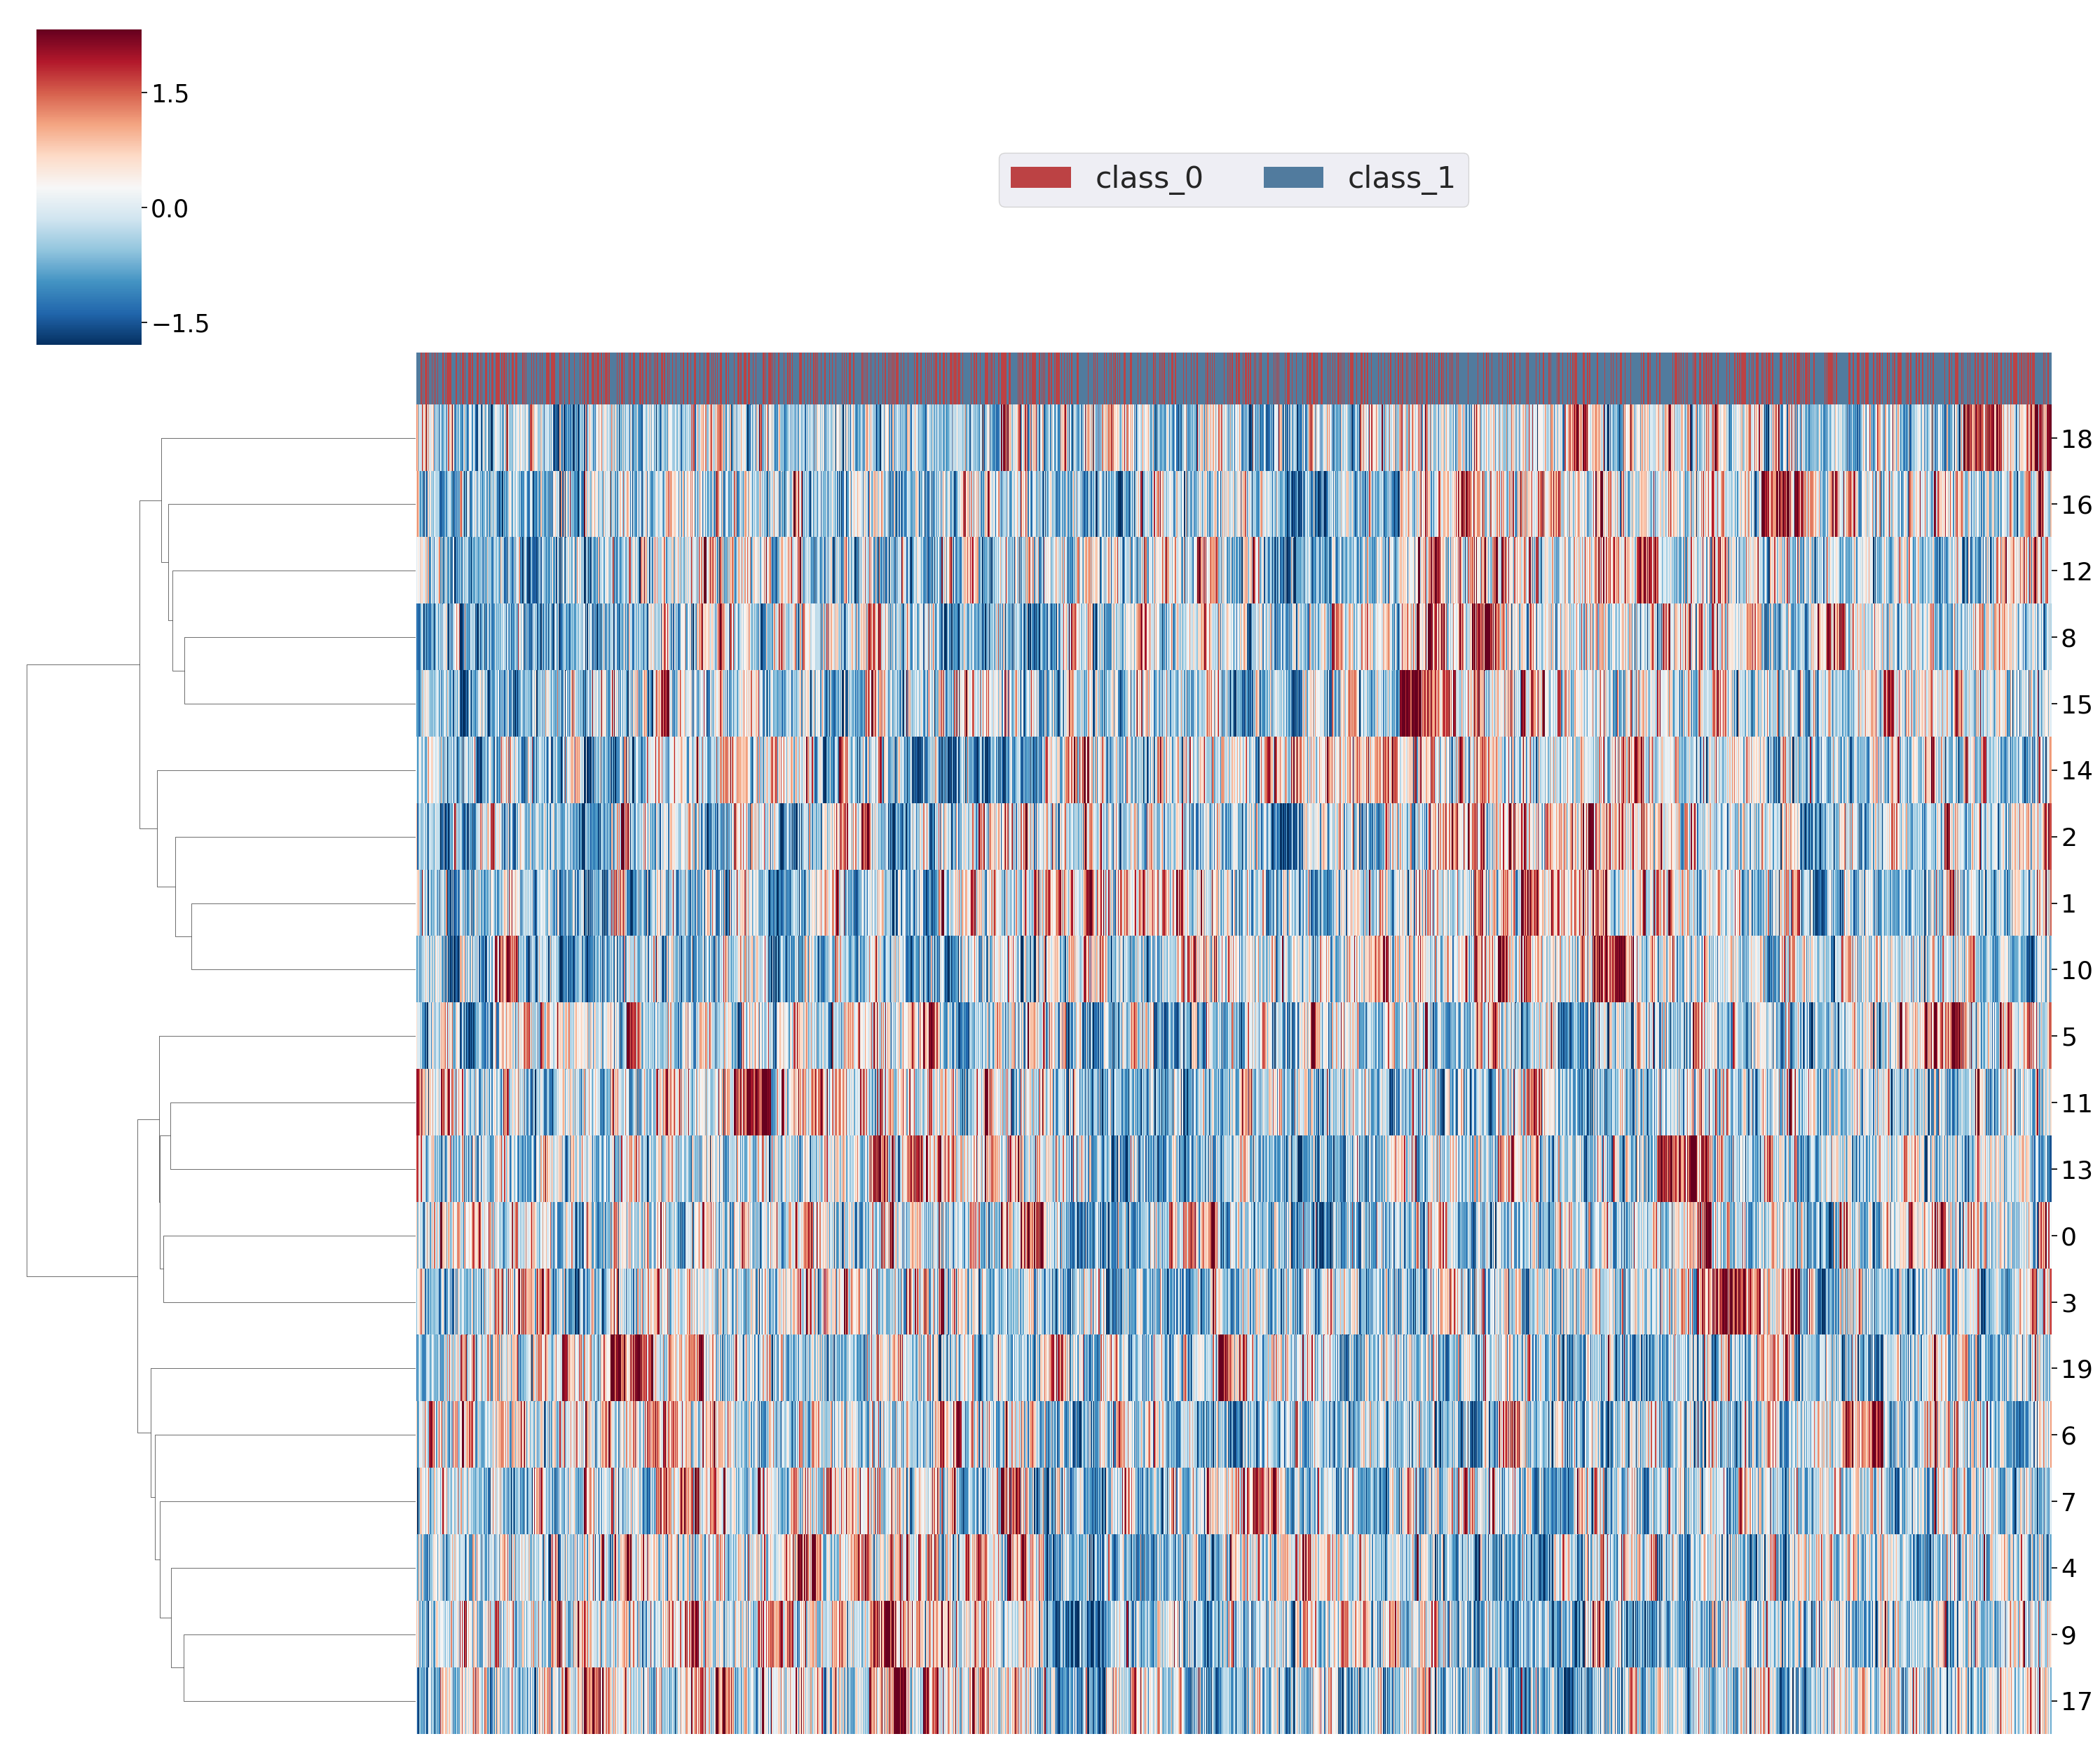

In [11]:
#save and evaluate

activations = model.get_max_activations(data, "test")
logos = model.visualize_all_kernels(activations, data, output_folder_p)

#utils.save_as_meme(logos, output_folder_p+"/"+"motifs_seq.meme")
utils.save_as_meme([logo[0] for logo in logos], output_folder_p+"/"+"motifs_seq.meme")
utils.save_as_meme([logo[1] for logo in logos], output_folder_p+"/"+"motifs_struct.meme")
model.plot_clustering(activations, output_folder_p+"/"+"clustering.png")
Image(output_folder_p+"/"+"clustering.png")

In [46]:
!jupyter nbconvert --to script Motif_pipeline.ipynb

[NbConvertApp] Converting notebook Motif_pipeline.ipynb to script
[NbConvertApp] Writing 23968 bytes to Motif_pipeline.py
